In [12]:
import pandas as pd
df = pd.read_csv('train.csv')
print(df.shape)

(891, 12)


In [13]:
# Step 1 — NumPy Warm-Up: Broadcasting & Masking
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
scores = np.random.randint(0, 100, (6, 4))
print("(a) Original Score Matrix (6 students x 4 exams):")
print(scores)

mins = scores.min(axis=0)
maxs = scores.max(axis=0)
normalized = (scores - mins) / (maxs - mins)
print("\n(b) Normalized Matrix (each column 0 to 1):")
print(normalized.round(3))

avg_scores = scores.mean(axis=1)
print("\n(c) Student Averages:", avg_scores.round(1))
mask = avg_scores >= 60
print("Passing mask:", mask)
passing_students = scores[mask]
print("Passing students scores:")
print(passing_students)

col_means = scores.mean(axis=0)
cleaned = np.where(scores < 40, col_means, scores)
print("\n(d) After replacing scores < 40 with column mean:")
print(cleaned.round(1))

weights = np.random.rand(4)
weights = weights / weights.sum()
weighted_scores = normalized @ weights
print("\n(e) Weight vector:", weights.round(3))
print("Weighted scores per student:", weighted_scores.round(3))
print("Ranking (best to worst):", np.argsort(weighted_scores)[::-1])

(a) Original Score Matrix (6 students x 4 exams):
[[51 92 14 71]
 [60 20 82 86]
 [74 74 87 99]
 [23  2 21 52]
 [ 1 87 29 37]
 [ 1 63 59 20]]

(b) Normalized Matrix (each column 0 to 1):
[[0.685 1.    0.    0.646]
 [0.808 0.2   0.932 0.835]
 [1.    0.8   1.    1.   ]
 [0.301 0.    0.096 0.405]
 [0.    0.944 0.205 0.215]
 [0.    0.678 0.616 0.   ]]

(c) Student Averages: [57.  62.  83.5 24.5 38.5 35.8]
Passing mask: [False  True  True False False False]
Passing students scores:
[[60 20 82 86]
 [74 74 87 99]]

(d) After replacing scores < 40 with column mean:
[[51.  92.  48.7 71. ]
 [60.  56.3 82.  86. ]
 [74.  74.  87.  99. ]
 [35.  56.3 48.7 52. ]
 [35.  87.  48.7 60.8]
 [35.  63.  59.  60.8]]

(e) Weight vector: [0.49  0.486 0.006 0.018]
Weighted scores per student: [0.833 0.514 0.903 0.156 0.464 0.333]
Ranking (best to worst): [2 0 1 4 5 3]


In [14]:
# Step 2 — Load Dataset & Full Initial Inspection
df = pd.read_csv('train.csv')

print("=" * 60)
print("FIRST 10 ROWS:")
print("=" * 60)
print(df.head(10))

print("=" * 60)
print("LAST 5 ROWS:")
print("=" * 60)
print(df.tail(5))

print("=" * 60)
print("RANDOM SAMPLE 8 ROWS:")
print("=" * 60)
print(df.sample(8, random_state=42))

print("=" * 60)
print("SHAPE:", df.shape)
print("=" * 60)
df.info()

print("\nData Types:")
print(df.dtypes)

print("\nColumn Names:")
print(df.columns.tolist())

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()
missing_cols = df.columns[df.isnull().any()].tolist()
total_missing = df.isnull().sum().sum()

print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns  ({len(num_cols)}): {num_cols}")
print(f"Columns with missing values: {missing_cols}")
print(f"Total missing cells: {total_missing}")

FIRST 10 ROWS:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timoth

=== MISSING VALUE ANALYSIS ===
          Missing Count  Percentage %
Cabin               687         77.10
Age                 177         19.87
Embarked              2          0.22


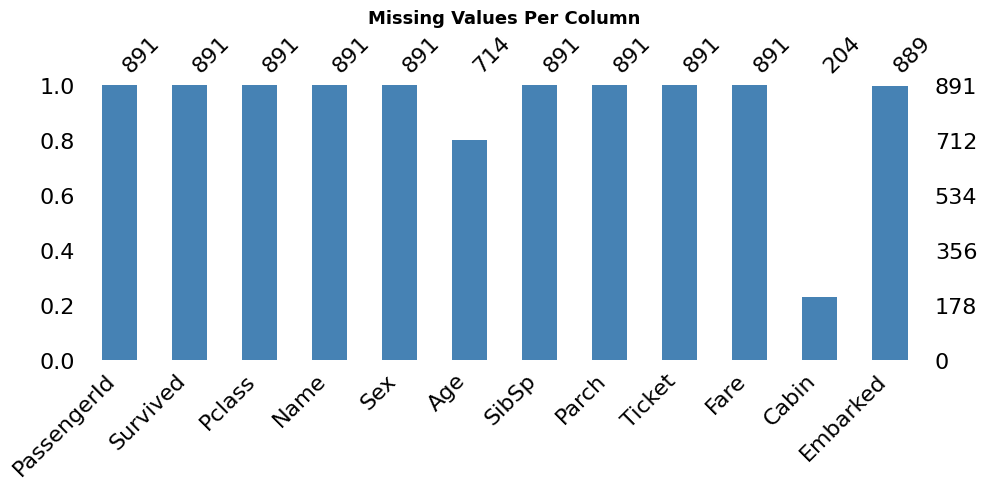


Top 3 columns with most missing data:
          Missing Count  Percentage %
Cabin               687         77.10
Age                 177         19.87
Embarked              2          0.22


In [15]:
# Step 3 — Missing Value Deep Analysis

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage %': missing_pct.round(2)
}).sort_values('Missing Count', ascending=False)

print("=== MISSING VALUE ANALYSIS ===")
print(missing_df[missing_df['Missing Count'] > 0])

!pip install missingno -q
import missingno as msno

plt.figure()
msno.bar(df, color='steelblue', figsize=(10, 5))
plt.title('Missing Values Per Column', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 3 columns with most missing data:")
print(missing_df.head(3))

In [16]:
# Step 4 — Data Type Audit & Correction

old_dtypes = df.dtypes.copy()

print("=== BEFORE — Data Types ===")
print(old_dtypes)

print("\nUnique values in 'Survived':", df['Survived'].unique())
print("Unique values in 'Pclass':", df['Pclass'].unique())

df['Survived'] = pd.Categorical(df['Survived'])
df['Pclass']   = pd.Categorical(df['Pclass'])
df['Sex']      = pd.Categorical(df['Sex'])
df['Embarked'] = pd.Categorical(df['Embarked'])

print("\n=== AFTER — Data Types ===")
print(df.dtypes)

comparison = pd.DataFrame({
    'Column':   df.columns,
    'Old dtype': old_dtypes.values,
    'New dtype': df.dtypes.values
})
print("\n=== BEFORE vs AFTER COMPARISON ===")
print(comparison)

print("\n=== df.info() AFTER FIXING ===")
df.info()

=== BEFORE — Data Types ===
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Unique values in 'Survived': [0 1]
Unique values in 'Pclass': [3 1 2]

=== AFTER — Data Types ===
PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked       category
dtype: object

=== BEFORE vs AFTER COMPARISON ===
         Column Old dtype New dtype
0   PassengerId     int64     int64
1      Survived     int64  category
2        Pclass     int64  category
3          Name    object    object
4           Sex    object  category
5           Age   float64   f

In [17]:
# Step 5 — Handle Missing Values — Professional Strategy

print("=== MISSING BEFORE CLEANING ===")
print(df.isnull().sum())

df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
print("\nAge missing after group imputation:", df['Age'].isnull().sum())

embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print("Embarked missing after fill:", df['Embarked'].isnull().sum())
print("Embarked filled with:", embarked_mode)

df['has_cabin'] = df['Cabin'].notnull().astype(int)
df.drop(columns=['Cabin'], inplace=True)
print("\nhas_cabin value counts:")
print(df['has_cabin'].value_counts())

print("\n=== MISSING AFTER ALL CLEANING ===")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

strategy_df = pd.DataFrame({
    'Column':   ['Age', 'Embarked', 'Cabin'],
    'Strategy': [
        'Group median by Pclass + Sex',
        'Fill with mode (S)',
        'Created has_cabin binary + dropped'
    ],
    'Reason': [
        'Age varies by class & gender — group median more accurate',
        'Only 2 missing — mode is safe',
        '77% missing — imputation would be mostly artificial'
    ]
})
print("\n=== CLEANING STRATEGY SUMMARY ===")
print(strategy_df)

=== MISSING BEFORE CLEANING ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Age missing after group imputation: 0
Embarked missing after fill: 0
Embarked filled with: S

has_cabin value counts:
has_cabin
0    687
1    204
Name: count, dtype: int64

=== MISSING AFTER ALL CLEANING ===
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
has_cabin      0
dtype: int64

Total missing cells: 0

=== CLEANING STRATEGY SUMMARY ===
     Column                            Strategy  \
0       Age        Group median by Pclass + Sex   
1  Embarked                  Fill with mode (S)   
2     Cabin  Created has_cabin binary + dropped   

                                     

=== FARE OUTLIER ANALYSIS ===
Q1: 7.91 | Q3: 31.00 | IQR: 23.09
Lower fence: -26.72 | Upper fence: 65.63
Fare outliers: 116 passengers
99th percentile fare: 249.01

=== AGE OUTLIER ANALYSIS ===
Q1: 21.50 | Q3: 36.00 | IQR: 14.50
Lower fence: -0.25 | Upper fence: 57.75
Age outliers: 33 passengers
Age outlier treatment: NONE — elderly passengers are real data


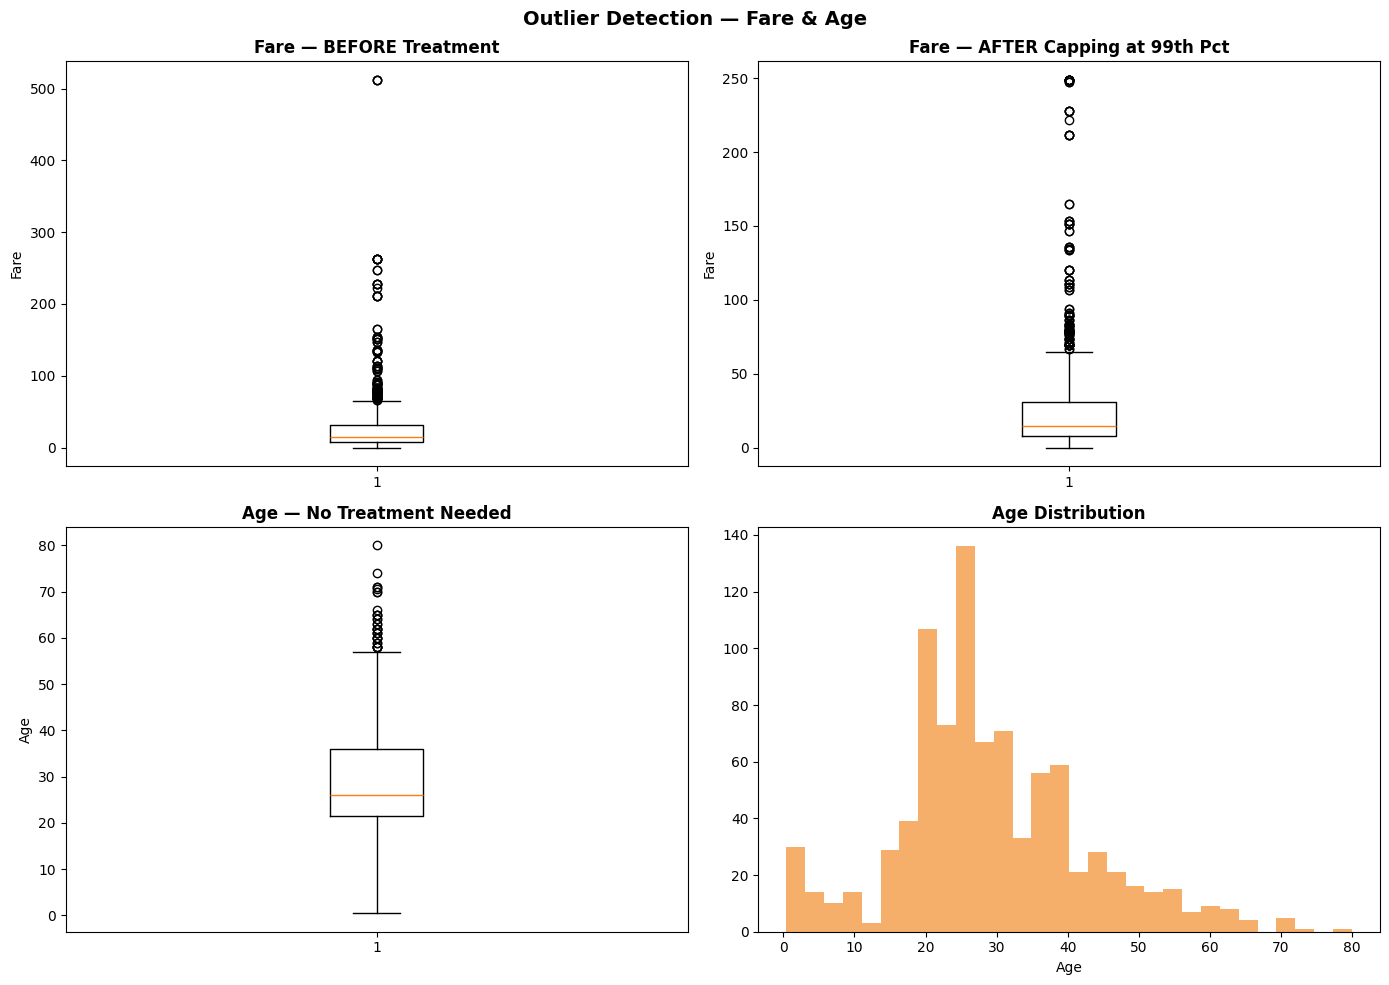

In [18]:
# Step 6 — Outlier Detection & Treatment

df['Age'] = df['Age'].astype(float)
df['Fare'] = df['Fare'].astype(float)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[(df['Fare'] < lower_fare) | (df['Fare'] > upper_fare)]
print(f"=== FARE OUTLIER ANALYSIS ===")
print(f"Q1: {Q1_fare:.2f} | Q3: {Q3_fare:.2f} | IQR: {IQR_fare:.2f}")
print(f"Lower fence: {lower_fare:.2f} | Upper fence: {upper_fare:.2f}")
print(f"Fare outliers: {len(fare_outliers)} passengers")

axes[0, 0].boxplot(df['Fare'])
axes[0, 0].set_title('Fare — BEFORE Treatment', fontweight='bold')
axes[0, 0].set_ylabel('Fare')

p99_fare = df['Fare'].quantile(0.99)
print(f"99th percentile fare: {p99_fare:.2f}")
df['Fare'] = df['Fare'].clip(upper=p99_fare)

axes[0, 1].boxplot(df['Fare'])
axes[0, 1].set_title('Fare — AFTER Capping at 99th Pct', fontweight='bold')
axes[0, 1].set_ylabel('Fare')

Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[(df['Age'] < lower_age) | (df['Age'] > upper_age)]
print(f"\n=== AGE OUTLIER ANALYSIS ===")
print(f"Q1: {Q1_age:.2f} | Q3: {Q3_age:.2f} | IQR: {IQR_age:.2f}")
print(f"Lower fence: {lower_age:.2f} | Upper fence: {upper_age:.2f}")
print(f"Age outliers: {len(age_outliers)} passengers")
print("Age outlier treatment: NONE — elderly passengers are real data")

axes[1, 0].boxplot(df['Age'])
axes[1, 0].set_title('Age — No Treatment Needed', fontweight='bold')
axes[1, 0].set_ylabel('Age')

axes[1, 1].hist(df['Age'], bins=30, color='#f28e2b', alpha=0.7)
axes[1, 1].set_title('Age Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Age')

plt.suptitle('Outlier Detection — Fare & Age',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Step 7 — Feature Engineering — 7 New Columns

df['family_size'] = df['SibSp'] + df['Parch'] + 1
print("(a) family_size value counts:")
print(df['family_size'].value_counts().sort_index())

df['is_alone'] = (df['family_size'] == 1).astype(int)
print("\n(b) is_alone value counts:")
print(df['is_alone'].value_counts())

df['fare_per_person'] = df['Fare'] / df['family_size']
print("\n(c) fare_per_person — first 5 values:")
print(df['fare_per_person'].head())

df['title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print("\n(d) Title counts before grouping:")
print(df['title'].value_counts())

rare_titles = ['Dr','Rev','Col','Major','Mlle','Countess',
               'Ms','Lady','Jonkheer','Don','Dona','Capt','Sir']
df['title'] = df['title'].replace(rare_titles, 'Rare')
df['title'] = df['title'].replace({'Mme': 'Mrs'})
print("\nTitle counts after grouping:")
print(df['title'].value_counts())

bins = [0, 12, 17, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)
print("\n(e) age_group value counts:")
print(df['age_group'].value_counts())

df['deck'] = np.where(df['has_cabin'] == 1, 'Known', 'Unknown')
print("\n(f) deck value counts:")
print(df['deck'].value_counts())

df['fare_bin'] = pd.qcut(df['Fare'], q=4,
                          labels=['Low','Medium','High','VHigh'])
print("\n(g) fare_bin value counts:")
print(df['fare_bin'].value_counts())

new_cols = ['family_size','is_alone','fare_per_person',
            'title','age_group','deck','fare_bin']
print("\n=== FIRST 10 ROWS — ALL 7 NEW FEATURES ===")
print(df[new_cols].head(10))

(a) family_size value counts:
family_size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

(b) is_alone value counts:
is_alone
1    537
0    354
Name: count, dtype: int64

(c) fare_per_person — first 5 values:
0     3.62500
1    35.64165
2     7.92500
3    26.55000
4     8.05000
Name: fare_per_person, dtype: float64

(d) Title counts before grouping:
title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

Title counts after grouping:
title
Mr        517
Miss      182
Mrs       126
Master     40
Rare       26
Name: count, dtype: int64

(e) age_group value counts:
age_group
Adult     756
Child      69
Teen       44
Senior     22
Name: count, dtype: int64

(f) deck value counts

In [20]:
# Step 8 — Encoding Categorical Variables

df['sex_encoded'] = df['Sex'].map({'male': 0, 'female': 1})
print("(a) Sex encoding:")
print(df[['Sex', 'sex_encoded']].value_counts())

embarked_dummies = pd.get_dummies(df['Embarked'],
                                   prefix='Embarked')
df = pd.concat([df, embarked_dummies], axis=1)
print("\n(b) Embarked One-Hot Encoded columns:")
print(df[['Embarked','Embarked_C','Embarked_Q','Embarked_S']].head())

title_dummies = pd.get_dummies(df['title'],
                                prefix='title',
                                drop_first=False)
title_dummies.drop(columns=['title_Mr'], inplace=True)
df = pd.concat([df, title_dummies], axis=1)
print("\n(c) Title encoded columns:")
print(title_dummies.head())

age_map = {'Child': 0, 'Teen': 1, 'Adult': 2, 'Senior': 3}
df['age_group_encoded'] = df['age_group'].map(age_map)
print("\n(d) age_group ordinal encoding:")
print(df[['age_group', 'age_group_encoded']].value_counts())

fare_map = {'Low': 0, 'Medium': 1, 'High': 2, 'VHigh': 3}
df['fare_bin_encoded'] = df['fare_bin'].map(fare_map)
print("\nfare_bin ordinal encoding:")
print(df[['fare_bin', 'fare_bin_encoded']].value_counts())

print(f"\n=== SHAPE AFTER ENCODING: {df.shape} ===")

ml_features = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch',
               'Fare', 'has_cabin', 'family_size', 'is_alone',
               'fare_per_person', 'sex_encoded', 'age_group_encoded',
               'fare_bin_encoded', 'Embarked_C', 'Embarked_Q',
               'Embarked_S', 'title_Master', 'title_Miss',
               'title_Mrs', 'title_Rare']

print("\n=== ML FEATURE LIST ===")
print(ml_features)
print(f"Total features: {len(ml_features)}")

(a) Sex encoding:
Sex     sex_encoded
male    0              577
female  1              314
Name: count, dtype: int64

(b) Embarked One-Hot Encoded columns:
  Embarked  Embarked_C  Embarked_Q  Embarked_S
0        S       False       False        True
1        C        True       False       False
2        S       False       False        True
3        S       False       False        True
4        S       False       False        True

(c) Title encoded columns:
   title_Master  title_Miss  title_Mrs  title_Rare
0         False       False      False       False
1         False       False       True       False
2         False        True      False       False
3         False       False       True       False
4         False       False      False       False

(d) age_group ordinal encoding:
age_group  age_group_encoded
Adult      2                    756
Child      0                     69
Teen       1                     44
Senior     3                     22
Name: count, dtype: i

In [21]:
# Step 9 — Feature Scaling & Final ML-Ready Dataset
from sklearn.preprocessing import StandardScaler

scale_cols = ['Age', 'Fare', 'fare_per_person', 'family_size']

print("=== BEFORE SCALING ===")
for col in scale_cols:
    print(f"{col}: mean={df[col].mean():.2f}, std={df[col].std():.2f}")

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("\n=== AFTER SCALING ===")
for col in scale_cols:
    print(f"{col}: mean={df[col].mean():.4f}, std={df[col].std():.4f}")

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

drop_cols = ['Name', 'Ticket', 'PassengerId', 'Sex',
             'Embarked', 'title', 'age_group', 'fare_bin',
             'SibSp', 'Parch', 'deck']

drop_cols = [c for c in drop_cols if c in df.columns]
final_df = df[ml_features].copy()

final_df['Survived'] = final_df['Survived'].astype(int)
final_df['Pclass'] = final_df['Pclass'].astype(int)

print("\n=== FINAL ML-READY DATASET ===")
print(f"Shape: {final_df.shape}")
final_df.info()
print("\nFirst 5 rows:")
print(final_df.head())

final_df.to_csv('titanic_cleaned.csv', index=False)
print("\ntitanic_cleaned.csv saved!")

=== BEFORE SCALING ===
Age: mean=29.11, std=13.30
Fare: mean=31.22, std=42.52
fare_per_person: mean=19.16, std=28.39
family_size: mean=1.90, std=1.61

=== AFTER SCALING ===
Age: mean=0.0000, std=1.0006
Fare: mean=-0.0000, std=1.0006
fare_per_person: mean=0.0000, std=1.0006
family_size: mean=-0.0000, std=1.0006

=== FINAL ML-READY DATASET ===
Shape: (891, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Survived           891 non-null    int64   
 1   Pclass             891 non-null    int64   
 2   Age                891 non-null    float64 
 3   SibSp              891 non-null    int64   
 4   Parch              891 non-null    int64   
 5   Fare               891 non-null    float64 
 6   has_cabin          891 non-null    int64   
 7   family_size        891 non-null    float64 
 8   is_alone           891 non-null    int6

Overall survival rate: 0.384

(a) Survival by Pclass:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

(b) Survival by Sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

(c) Survival by Pclass + Sex:
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135

(d) Survival by age_group:
age_group
Child     0.580
Teen      0.477
Adult     0.365
Senior    0.227
Name: Survived, dtype: float64

(e) Survival by is_alone:
is_alone
0    0.506
1    0.304
Name: Survived, dtype: float64

(f) Survival by Embarked:
Embarked
C    0.554
Q    0.390
S    0.339
Name: Survived, dtype: float64


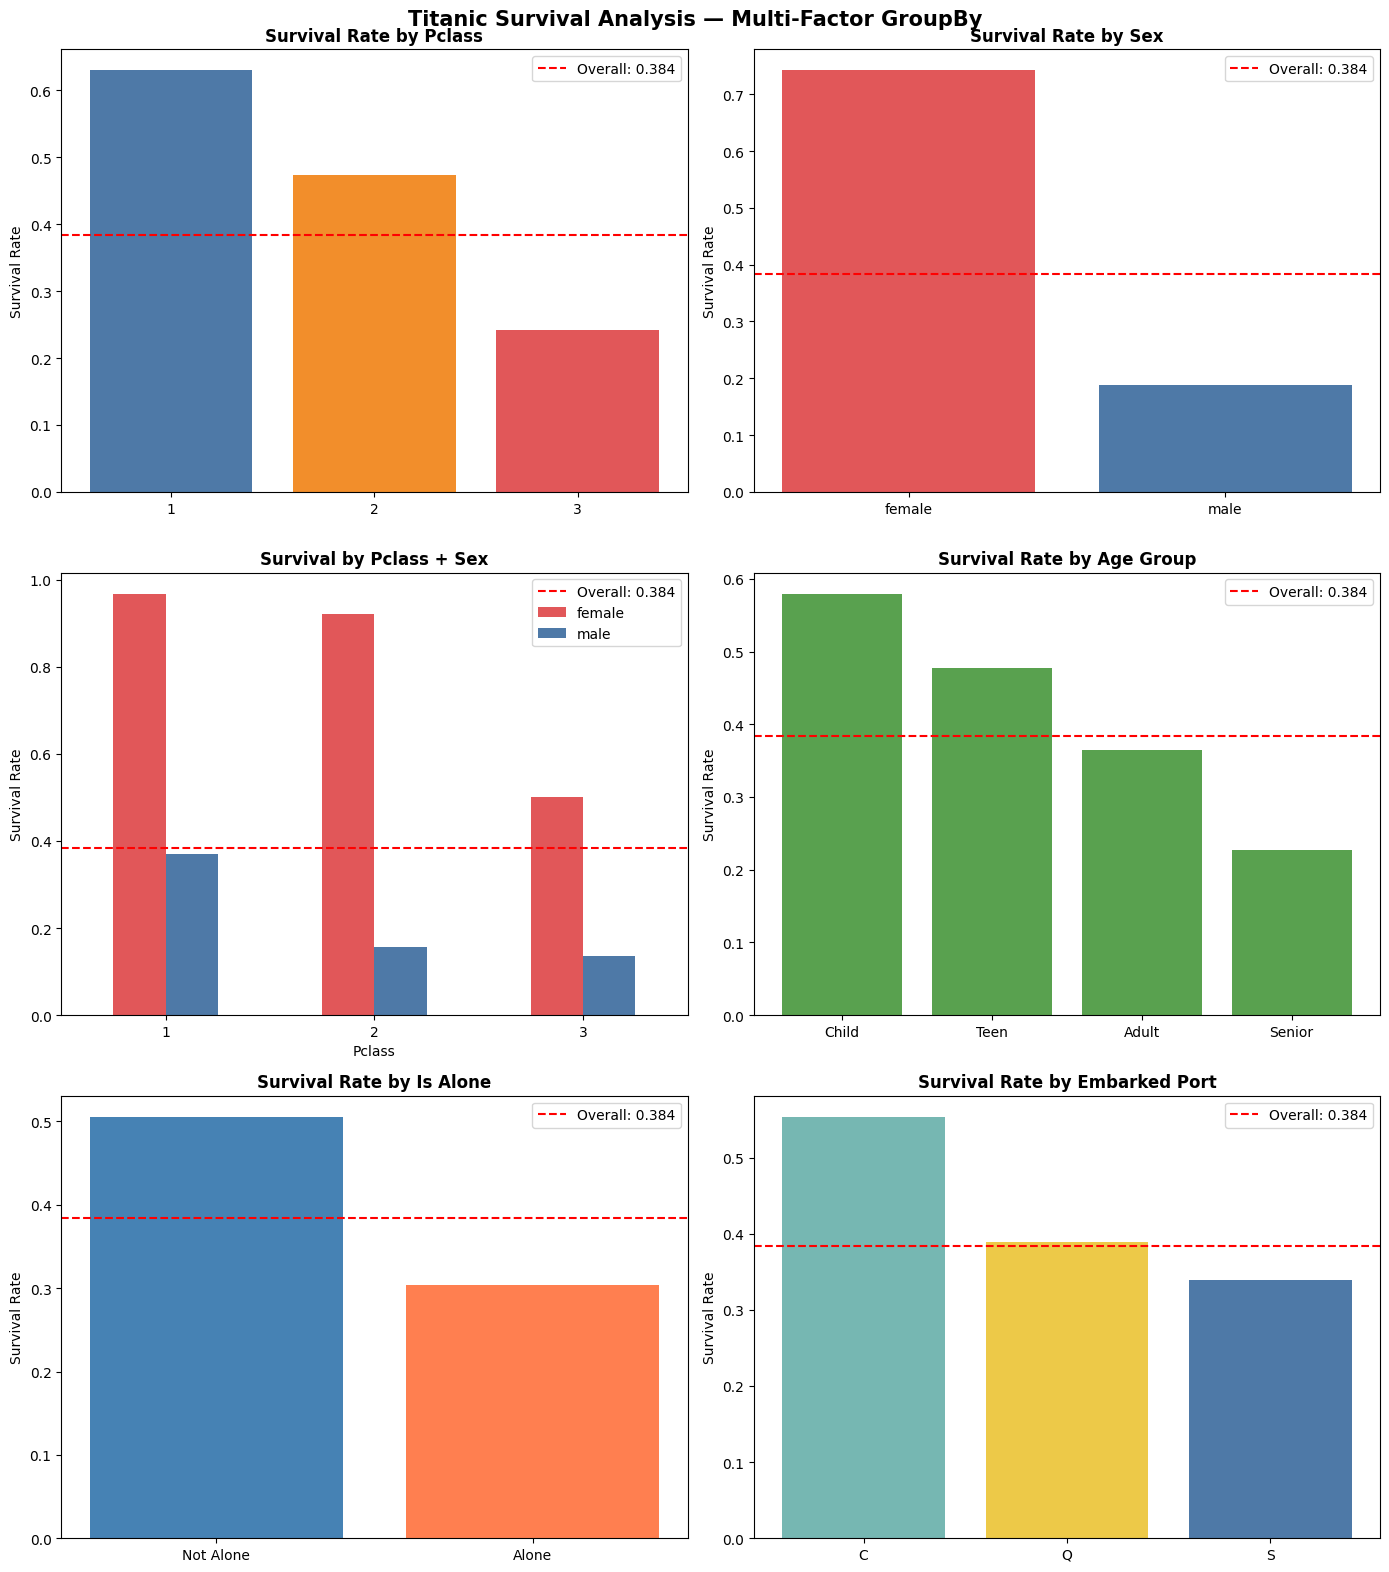

In [22]:
# Step 10 — Survival Analysis — Multi-Factor GroupBy

df_orig = pd.read_csv('train.csv')
df_orig['Age'] = df_orig.groupby(['Pclass','Sex'])['Age'].transform(
    lambda x: x.fillna(x.median()))
df_orig['Embarked'] = df_orig['Embarked'].fillna('S')
df_orig['has_cabin'] = df_orig['Cabin'].notnull().astype(int)

df_orig['family_size'] = df_orig['SibSp'] + df_orig['Parch'] + 1
df_orig['is_alone'] = (df_orig['family_size'] == 1).astype(int)
bins = [0, 12, 17, 60, 100]
labels = ['Child','Teen','Adult','Senior']
df_orig['age_group'] = pd.cut(df_orig['Age'], bins=bins, labels=labels)
df_orig['title'] = df_orig['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
rare = ['Dr','Rev','Col','Major','Mlle','Countess','Ms',
        'Lady','Jonkheer','Don','Dona','Capt','Sir']
df_orig['title'] = df_orig['title'].replace(rare, 'Rare')
df_orig['title'] = df_orig['title'].replace({'Mme':'Mrs'})

overall_rate = df_orig['Survived'].mean()
print(f"Overall survival rate: {overall_rate:.3f}")

fig, axes = plt.subplots(3, 2, figsize=(14, 16))

pclass_surv = df_orig.groupby('Pclass')['Survived'].mean()
print("\n(a) Survival by Pclass:")
print(pclass_surv.round(3))
axes[0,0].bar(pclass_surv.index.astype(str), pclass_surv.values,
              color=['#4e79a7','#f28e2b','#e15759'])
axes[0,0].axhline(overall_rate, color='red', linestyle='--',
                   label=f'Overall: {overall_rate:.3f}')
axes[0,0].set_title('Survival Rate by Pclass', fontweight='bold')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].legend()

sex_surv = df_orig.groupby('Sex')['Survived'].mean()
print("\n(b) Survival by Sex:")
print(sex_surv.round(3))
axes[0,1].bar(sex_surv.index, sex_surv.values,
              color=['#e15759','#4e79a7'])
axes[0,1].axhline(overall_rate, color='red', linestyle='--',
                   label=f'Overall: {overall_rate:.3f}')
axes[0,1].set_title('Survival Rate by Sex', fontweight='bold')
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].legend()

pclass_sex = df_orig.groupby(['Pclass','Sex'])['Survived'].mean().unstack()
print("\n(c) Survival by Pclass + Sex:")
print(pclass_sex.round(3))
pclass_sex.plot(kind='bar', ax=axes[1,0],
                color=['#e15759','#4e79a7'])
axes[1,0].axhline(overall_rate, color='red', linestyle='--',
                   label=f'Overall: {overall_rate:.3f}')
axes[1,0].set_title('Survival by Pclass + Sex', fontweight='bold')
axes[1,0].set_ylabel('Survival Rate')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend()

age_surv = df_orig.groupby('age_group', observed=True)['Survived'].mean()
print("\n(d) Survival by age_group:")
print(age_surv.round(3))
axes[1,1].bar(age_surv.index.astype(str), age_surv.values,
              color='#59a14f')
axes[1,1].axhline(overall_rate, color='red', linestyle='--',
                   label=f'Overall: {overall_rate:.3f}')
axes[1,1].set_title('Survival Rate by Age Group', fontweight='bold')
axes[1,1].set_ylabel('Survival Rate')
axes[1,1].legend()

alone_surv = df_orig.groupby('is_alone')['Survived'].mean()
print("\n(e) Survival by is_alone:")
print(alone_surv.round(3))
axes[2,0].bar(['Not Alone','Alone'], alone_surv.values,
              color=['steelblue','coral'])
axes[2,0].axhline(overall_rate, color='red', linestyle='--',
                   label=f'Overall: {overall_rate:.3f}')
axes[2,0].set_title('Survival Rate by Is Alone', fontweight='bold')
axes[2,0].set_ylabel('Survival Rate')
axes[2,0].legend()

emb_surv = df_orig.groupby('Embarked')['Survived'].mean()
print("\n(f) Survival by Embarked:")
print(emb_surv.round(3))
axes[2,1].bar(emb_surv.index, emb_surv.values,
              color=['#76b7b2','#edc948','#4e79a7'])
axes[2,1].axhline(overall_rate, color='red', linestyle='--',
                   label=f'Overall: {overall_rate:.3f}')
axes[2,1].set_title('Survival Rate by Embarked Port', fontweight='bold')
axes[2,1].set_ylabel('Survival Rate')
axes[2,1].legend()

plt.suptitle('Titanic Survival Analysis — Multi-Factor GroupBy',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# Step 11 — Advanced Aggregation — agg() with Custom Functions

pct_above_50 = lambda x: (x > 50).mean() * 100
iqr = lambda x: x.quantile(0.75) - x.quantile(0.25)

fare_stats = df_orig.groupby('Pclass')['Fare'].agg(
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max',
    pct_above_50=pct_above_50
).round(2)

age_stats = df_orig.groupby('Pclass')['Age'].agg(
    mean='mean',
    median='median',
    iqr=iqr
).round(2)

surv_stats = df_orig.groupby('Pclass')['Survived'].agg(
    survival_rate='mean',
    count='count'
).round(3)

print("=== FARE STATS BY PCLASS ===")
print(fare_stats)

print("\n=== AGE STATS BY PCLASS ===")
print(age_stats)

print("\n=== SURVIVAL STATS BY PCLASS ===")
print(surv_stats)

df_orig['class_avg_fare'] = df_orig.groupby('Pclass')['Fare'].transform('mean').round(2)
df_orig['class_survival_rate'] = df_orig.groupby('Pclass')['Survived'].transform('mean').round(3)

print("\n=== FIRST 15 ROWS WITH GROUP STATS ===")
print(df_orig[['PassengerId','Pclass','Fare','Survived',
               'class_avg_fare','class_survival_rate']].head(15))

=== FARE STATS BY PCLASS ===
         mean  median    std  min     max  pct_above_50
Pclass                                                 
1       84.15   60.29  78.38  0.0  512.33         64.35
2       20.66   14.25  13.42  0.0   73.50          3.80
3       13.68    8.05  11.78  0.0   69.55          2.85

=== AGE STATS BY PCLASS ===
         mean  median    iqr
Pclass                      
1       38.27    38.0  18.25
2       29.86    30.0  13.00
3       24.80    25.0   8.75

=== SURVIVAL STATS BY PCLASS ===
        survival_rate  count
Pclass                      
1               0.630    216
2               0.473    184
3               0.242    491

=== FIRST 15 ROWS WITH GROUP STATS ===
    PassengerId  Pclass     Fare  Survived  class_avg_fare  \
0             1       3   7.2500         0           13.68   
1             2       1  71.2833         1           84.15   
2             3       3   7.9250         1           13.68   
3             4       1  53.1000         1        

=== PIVOT A: Pclass × Sex → Survival Rate ===
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135

=== PIVOT B: age_group × Pclass → Survival ===
            mean               count          
Pclass         1      2      3     1    2    3
age_group                                     
Child      0.750  1.000  0.417     4   17   48
Teen       1.000  0.667  0.300     8    6   30
Adult      0.642  0.411  0.218   190  158  408
Senior     0.214  0.333  0.200    14    3    5

=== PIVOT C: title × Pclass → Median Fare ===
Pclass       1     2      3
title                      
Master  120.00  26.0  28.51
Miss     91.75  13.0   8.76
Mr       42.40  13.0   7.90
Mrs      79.20  26.0  15.98
Rare     39.60  13.0    NaN


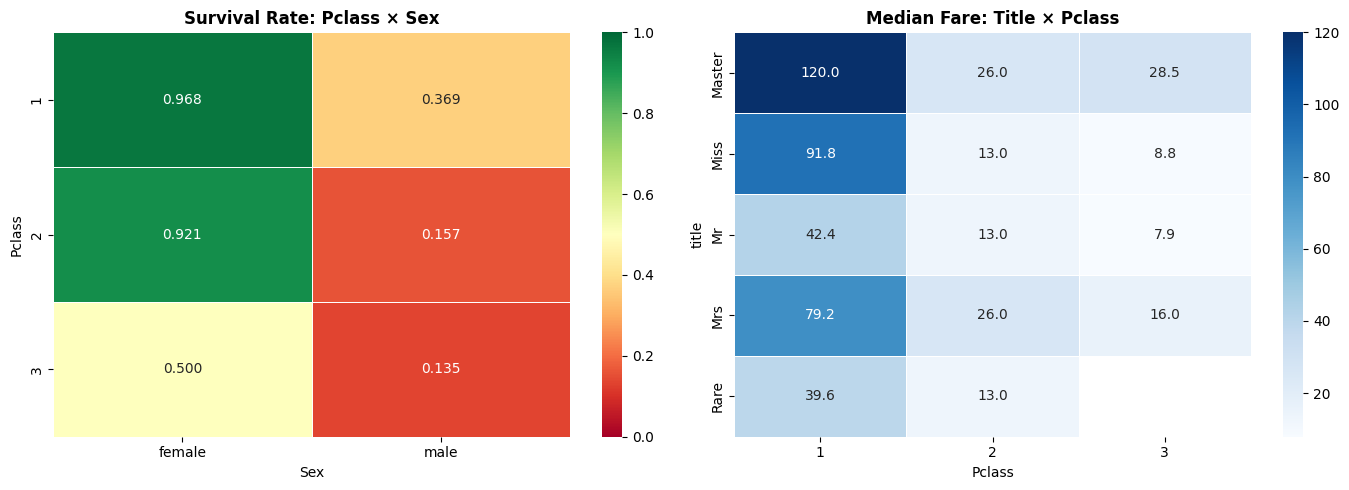

In [24]:
# Step 12 — Pivot Table Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_a = pd.pivot_table(df_orig,
                          index='Pclass',
                          columns='Sex',
                          values='Survived',
                          aggfunc='mean').round(3)
print("=== PIVOT A: Pclass × Sex → Survival Rate ===")
print(pivot_a)

sns.heatmap(pivot_a, annot=True, fmt='.3f',
            cmap='RdYlGn', ax=axes[0],
            linewidths=0.5, vmin=0, vmax=1)
axes[0].set_title('Survival Rate: Pclass × Sex',
                   fontweight='bold', fontsize=12)

pivot_b = pd.pivot_table(df_orig,
                          index='age_group',
                          columns='Pclass',
                          values='Survived',
                          aggfunc=['mean','count'],
                          observed=True).round(3)
print("\n=== PIVOT B: age_group × Pclass → Survival ===")
print(pivot_b)

pivot_c = pd.pivot_table(df_orig,
                          index='title',
                          columns='Pclass',
                          values='Fare',
                          aggfunc='median').round(2)
print("\n=== PIVOT C: title × Pclass → Median Fare ===")
print(pivot_c)

sns.heatmap(pivot_c, annot=True, fmt='.1f',
            cmap='Blues', ax=axes[1],
            linewidths=0.5)
axes[1].set_title('Median Fare: Title × Pclass',
                   fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

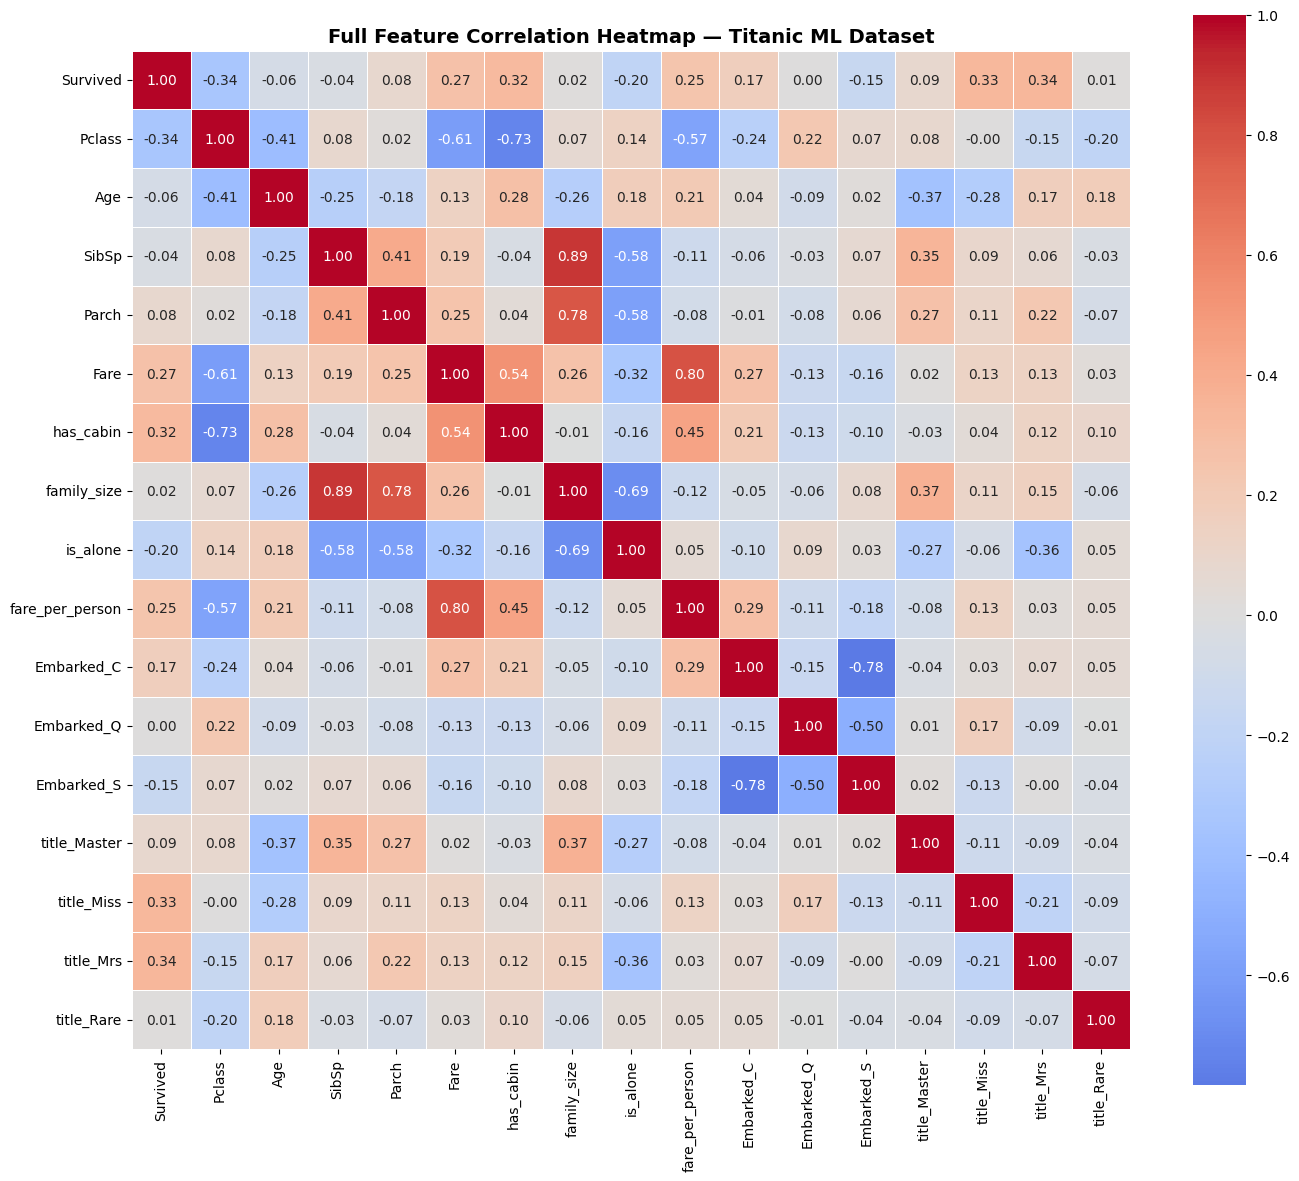

=== TOP FEATURES CORRELATED WITH SURVIVED ===
title_Mrs          0.342
Pclass             0.338
title_Miss         0.327
has_cabin          0.317
Fare               0.273
fare_per_person    0.246
is_alone           0.203
Embarked_C         0.168
Embarked_S         0.150
title_Master       0.085
Name: Survived, dtype: float64

=== HIGH CORRELATION PAIRS (> 0.7) ===
    Feature 1        Feature 2  Correlation
1       SibSp      family_size        0.891
3        Fare  fare_per_person        0.803
2       Parch      family_size        0.783
4  Embarked_C       Embarked_S        0.783
0      Pclass        has_cabin        0.726

=== NEAR-ZERO CORRELATION WITH SURVIVED (< 0.05) ===
SibSp          0.035
family_size    0.017
title_Rare     0.014
Embarked_Q     0.004
Name: Survived, dtype: float64

=== RANKED FEATURE-TO-SURVIVAL CORRELATIONS ===
title_Mrs          0.342
Pclass            -0.338
title_Miss         0.327
has_cabin          0.317
Fare               0.273
fare_per_person    0.246
i

In [25]:
# Step 13 — Correlation Analysis — Full Feature Set

corr_matrix = final_df.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Full Feature Correlation Heatmap — Titanic ML Dataset',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

surv_corr = corr_matrix['Survived'].drop('Survived').abs().sort_values(ascending=False)
print("=== TOP FEATURES CORRELATED WITH SURVIVED ===")
print(surv_corr.round(3).head(10))

print("\n=== HIGH CORRELATION PAIRS (> 0.7) ===")
high_corr = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = abs(corr_matrix.iloc[i, j])
        if val > 0.7:
            high_corr.append({
                'Feature 1': cols[i],
                'Feature 2': cols[j],
                'Correlation': round(val, 3)
            })
high_corr_df = pd.DataFrame(high_corr).sort_values(
    'Correlation', ascending=False)
print(high_corr_df)

print("\n=== NEAR-ZERO CORRELATION WITH SURVIVED (< 0.05) ===")
low_corr = surv_corr[surv_corr < 0.05]
print(low_corr.round(3))

print("\n=== RANKED FEATURE-TO-SURVIVAL CORRELATIONS ===")
ranked = corr_matrix['Survived'].drop('Survived').sort_values(
    key=abs, ascending=False)
print(ranked.round(3))

In [26]:
# Step 14 — NumPy Performance & Survival Computation

arr = final_df.select_dtypes(include='number').values
col_names = final_df.select_dtypes(include='number').columns.tolist()

print(f"Array shape: {arr.shape}")

print("\n=== (a) NUMPY STATS PER COLUMN ===")
stats_table = pd.DataFrame({
    'Column':  col_names,
    'Mean':    np.mean(arr, axis=0).round(4),
    'Std':     np.std(arr, axis=0).round(4),
    'Min':     np.min(arr, axis=0).round(4),
    'Max':     np.max(arr, axis=0).round(4),
    'Median':  np.median(arr, axis=0).round(4)
})
print(stats_table.to_string(index=False))

print("\n=== (b) Z-SCORE VERIFICATION ===")
z_matrix = (arr - np.mean(arr, axis=0)) / np.std(arr, axis=0)
print("Column means after z-score (should be ≈0):")
print(np.mean(z_matrix, axis=0).round(4))
print("Column stds after z-score (should be ≈1):")
print(np.std(z_matrix, axis=0).round(4))

print("\n=== (c) NUMPY vs PANDAS CORRELATION ===")
np_corr = np.corrcoef(arr.T)
pd_corr = final_df.select_dtypes(include='number').corr().values
diff = np.abs(np_corr - pd_corr).max()
print(f"Max difference between np.corrcoef and pd.corr: {diff:.6f}")
print(" They match!" if diff < 0.001 else " Mismatch found")

print("\n=== (d) SURVIVORS vs NON-SURVIVORS ===")
survived_mask = arr[:, col_names.index('Survived')] == 1
not_survived_mask = arr[:, col_names.index('Survived')] == 0

age_idx  = col_names.index('Age')
fare_idx = col_names.index('Fare')

surv_age  = np.mean(arr[survived_mask, age_idx])
nsurv_age = np.mean(arr[not_survived_mask, age_idx])
surv_fare  = np.mean(arr[survived_mask, fare_idx])
nsurv_fare = np.mean(arr[not_survived_mask, fare_idx])

print(f"Survivors    — Mean Age: {surv_age:.4f} | Mean Fare: {surv_fare:.4f}")
print(f"Non-Survivors — Mean Age: {nsurv_age:.4f} | Mean Fare: {nsurv_fare:.4f}")
print(f"\nFare difference (scaled): {surv_fare - nsurv_fare:.4f}")
print(f"Age difference (scaled):  {surv_age - nsurv_age:.4f}")

print(f"\nTotal survivors:     {survived_mask.sum()}")
print(f"Total non-survivors: {not_survived_mask.sum()}")

Array shape: (891, 17)

=== (a) NUMPY STATS PER COLUMN ===
         Column    Mean    Std     Min    Max  Median
       Survived  0.3838 0.4863  0.0000 1.0000  0.0000
         Pclass  2.3086 0.8356  1.0000 3.0000  3.0000
            Age  0.0000 1.0000 -2.1578 3.8270 -0.2341
          SibSp  0.5230 1.1021  0.0000 8.0000  0.0000
          Parch  0.3816 0.8056  0.0000 6.0000  0.0000
           Fare -0.0000 1.0000 -0.7347 5.1242 -0.3946
      has_cabin  0.2290 0.4202  0.0000 1.0000  0.0000
    family_size -0.0000 1.0000 -0.5610 5.6404 -0.5610
       is_alone  0.6027 0.4893  0.0000 1.0000  1.0000
fare_per_person  0.0000 1.0000 -0.6754 8.1014 -0.3828
     Embarked_C  0.1886 0.3912  0.0000 1.0000  0.0000
     Embarked_Q  0.0864 0.2810  0.0000 1.0000  0.0000
     Embarked_S  0.7250 0.4465  0.0000 1.0000  1.0000
   title_Master  0.0449 0.2071  0.0000 1.0000  0.0000
     title_Miss  0.2043 0.4032  0.0000 1.0000  0.0000
      title_Mrs  0.1414 0.3484  0.0000 1.0000  0.0000
     title_Rare  0.0292

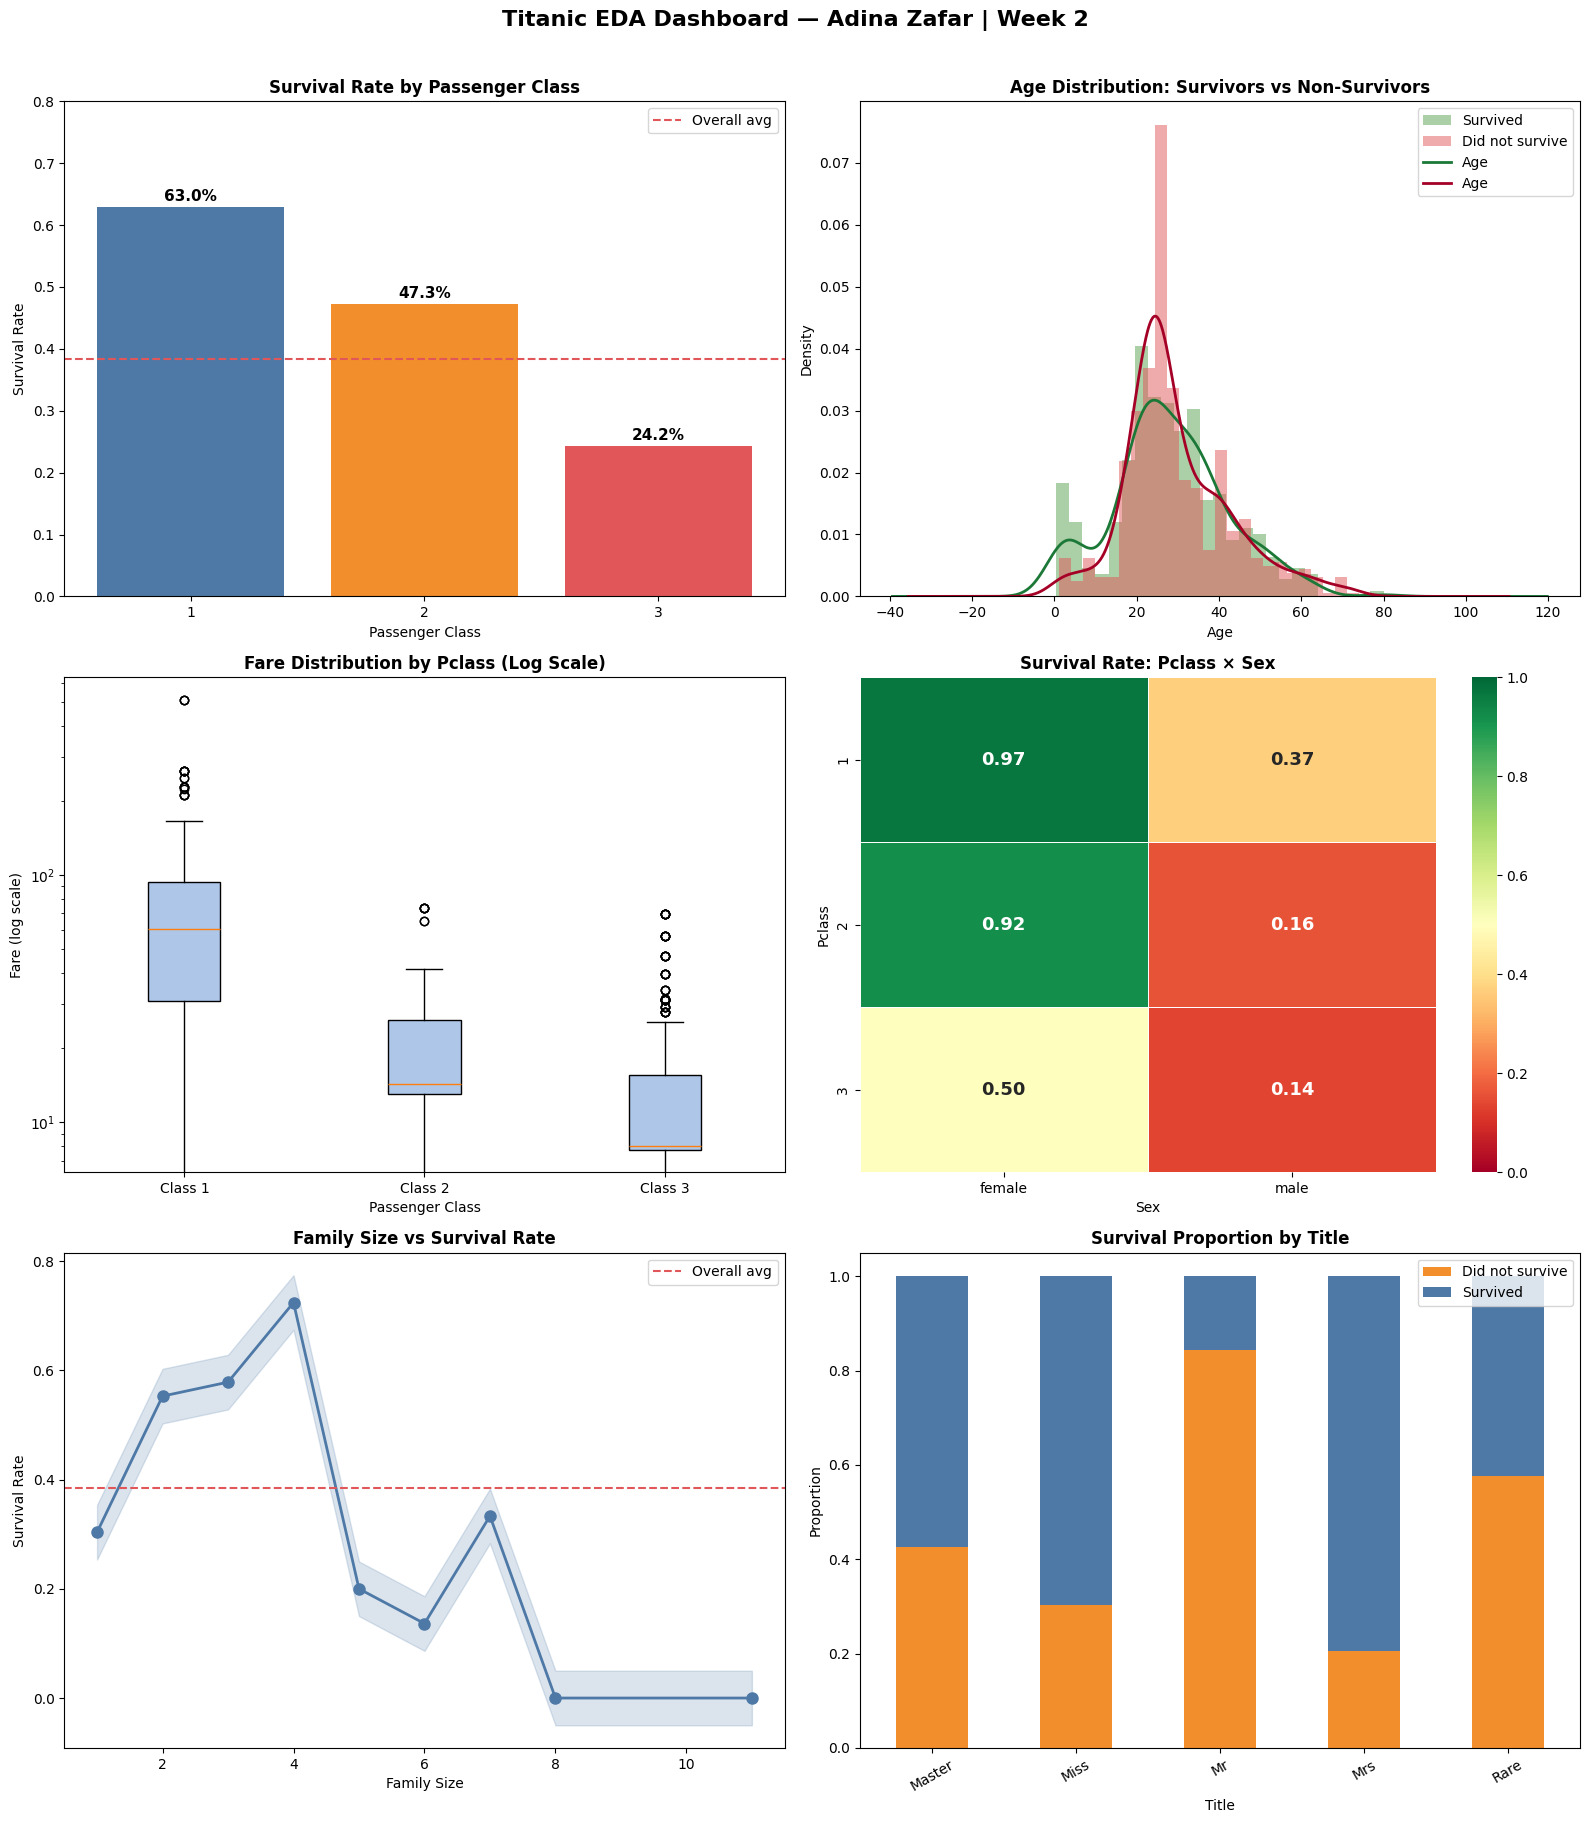

titanic_dashboard.png saved!


In [27]:
# Step 15 — Professional 6-Chart Titanic EDA Dashboard

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

pclass_surv = df_orig.groupby('Pclass')['Survived'].mean()
bars = axes[0,0].bar(pclass_surv.index.astype(str),
                      pclass_surv.values,
                      color=['#4e79a7','#f28e2b','#e15759'])
for bar, val in zip(bars, pclass_surv.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.01,
                   f'{val:.1%}', ha='center',
                   fontweight='bold', fontsize=11)
axes[0,0].set_title('Survival Rate by Passenger Class',
                     fontweight='bold', fontsize=12)
axes[0,0].set_xlabel('Passenger Class')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_ylim(0, 0.8)
axes[0,0].axhline(df_orig['Survived'].mean(), color='#e15759',
                   linestyle='--', label='Overall avg')
axes[0,0].legend()

surv = df_orig[df_orig['Survived']==1]['Age']
dead = df_orig[df_orig['Survived']==0]['Age']
axes[0,1].hist(surv, bins=25, alpha=0.5, color='#59a14f',
               density=True, label='Survived')
axes[0,1].hist(dead, bins=25, alpha=0.5, color='#e15759',
               density=True, label='Did not survive')
surv.plot.kde(ax=axes[0,1], color='#1b7837', linewidth=2)
dead.plot.kde(ax=axes[0,1], color='#a50026', linewidth=2)
axes[0,1].set_title('Age Distribution: Survivors vs Non-Survivors',
                     fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Density')
axes[0,1].legend()

pclass_groups = [df_orig[df_orig['Pclass']==i]['Fare'].values
                 for i in [1,2,3]]
axes[1,0].boxplot(pclass_groups, labels=['Class 1','Class 2','Class 3'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#aec6e8'))
axes[1,0].set_yscale('log')
axes[1,0].set_title('Fare Distribution by Pclass (Log Scale)',
                     fontweight='bold', fontsize=12)
axes[1,0].set_xlabel('Passenger Class')
axes[1,0].set_ylabel('Fare (log scale)')

pivot_heat = pd.pivot_table(df_orig, index='Pclass',
                             columns='Sex', values='Survived',
                             aggfunc='mean')
sns.heatmap(pivot_heat, annot=True, fmt='.2f',
            cmap='RdYlGn', ax=axes[1,1],
            linewidths=0.5, vmin=0, vmax=1,
            annot_kws={'size':13, 'weight':'bold'})
axes[1,1].set_title('Survival Rate: Pclass × Sex',
                     fontweight='bold', fontsize=12)

fam_surv = df_orig.groupby('family_size')['Survived'].agg(
    ['mean','count']).reset_index()
fam_surv.columns = ['family_size','survival_rate','count']
axes[2,0].plot(fam_surv['family_size'], fam_surv['survival_rate'],
               'o-', color='#4e79a7', linewidth=2, markersize=8)
axes[2,0].fill_between(fam_surv['family_size'],
                        fam_surv['survival_rate'] - 0.05,
                        fam_surv['survival_rate'] + 0.05,
                        alpha=0.2, color='#4e79a7')
axes[2,0].axhline(df_orig['Survived'].mean(), color='#e15759',
                   linestyle='--', label='Overall avg')
axes[2,0].set_title('Family Size vs Survival Rate',
                     fontweight='bold', fontsize=12)
axes[2,0].set_xlabel('Family Size')
axes[2,0].set_ylabel('Survival Rate')
axes[2,0].legend()

title_surv = df_orig.groupby('title')['Survived'].value_counts(
    normalize=True).unstack()
title_surv.plot(kind='bar', stacked=True, ax=axes[2,1],
                color=['#f28e2b','#4e79a7'])
axes[2,1].set_title('Survival Proportion by Title',
                     fontweight='bold', fontsize=12)
axes[2,1].set_xlabel('Title')
axes[2,1].set_ylabel('Proportion')
axes[2,1].tick_params(axis='x', rotation=30)
axes[2,1].legend(['Did not survive','Survived'])

plt.suptitle('Titanic EDA Dashboard — Adina Zafar | Week 2',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('titanic_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("titanic_dashboard.png saved!")

# Week 2 Analysis Report — Titanic Survival Dataset

## 1. Executive Summary
This week I analyzed the Titanic training dataset which has 891 passengers and 12 columns. The goal was to clean the messy real data, engineer useful features, and figure out what factors actually determined who survived and who didn't. Unlike Week 1 where the dataset was already perfectly clean, this one had real problems. Missing ages, a cabin column that was 77% empty, and some extreme fare values so most of my time went into data preparation before I could even start the interesting analysis.

The three findings that stood out most to me: gender was by far the strongest survival factor, females survived at 74.2% while males survived at only 18.9%, which is a massive gap. Passenger class was second, first class passengers survived at 63% vs 24.2% in third class. And the most striking single number I found was the Pclass × Sex combination: first class females survived at 96.8% while third class males survived at only 13.5%. That 83 percentage point gap between those two groups is the most extreme thing in the whole dataset.

## 2. Data Quality Assessment
The raw dataset had three columns with missing values. Age was missing for 177 passengers (19.9%) which is significant. I couldn't just drop those rows or I would lose nearly 20% of the data. Instead of filling with the global mean, I used group median by Pclass and Sex because a 1st class adult man probably had a different typical age than a 3rd class child. That felt like a smarter approach even though it was more code to write.

Cabin was the worst, 687 missing (77.1%). There is no sensible way to impute a column that is three quarters empty, so I created a binary has cabin column (1 if cabin was recorded, 0 if not) and dropped the original. The reasoning is that having a recorded cabin probably means the passenger was wealthy and in a higher class, so the information is not totally lost.

Embarked only had 2 missing values so I just filled those with the mode (Southampton, which was the most common). After all of this the dataset had zero missing values which was satisfying to verify.

## 3. Feature Engineering Rationale
I created 7 new features this week. family_size adds SibSp and Parch together and adds 1 for the passenger themselves. This was interesting because medium sized families (2-4 people) actually survived better than people traveling alone or in very large groups. is_alone flags solo travelers (family_size == 1) which made the survival difference clearer: 50.6% for people with family vs 30.4% alone.

fare_per_person divides the fare by family size since tickets were often shared, a £30 ticket split 4 ways is very different from one person paying £30. Title extraction was probably the most interesting feature to make. I had to use regex to pull titles like Mr, Mrs, Miss, Master out of the name column. Master specifically identifies young boys which is useful since gender alone doesn't capture age for males. age_group bins the continuous age into Child/Teen/Adult/Senior which made survival patterns easier to analyze. fare_bin divides fares into quartiles as a simpler socioeconomic indicator.

## 4. Key Statistical Findings

Overall survival rate was 38.4%. The biggest finding was gender: females 74.2%, males 18.9%. I was honestly surprised by how large this gap was, 55 percentage points is huge.

Pclass survival rates: Class 1 = 63.0%, Class 2 = 47.3%, Class 3 = 24.2%. The pattern is very clear and consistent. When you combine Pclass and Sex together you get the extremes: Class 1 female = 96.8% and Class 3 male = 13.5%.

Age group survival: Children = 58.0%, Teens = 47.7%, Adults = 36.5%, Seniors = 22.7%. This makes sense given "women and children first." Passengers with family (is_alone=0) survived at 50.6% vs 30.4% for solo travelers — group coordination during evacuation probably helped. Cherbourg passengers survived at 55.4%, the highest of any port, likely because many wealthy passengers boarded there.

Survivors also paid significantly higher fares on average, £48.40 vs £22.12 for non-survivors. That is more than double, which confirms that wealth was a big factor in survival.

## 5. Visualization Insights
The 6-chart dashboard I made covers the main angles of the analysis. The Pclass bar chart with value labels on top makes the 63% vs 24% difference immediately obvious without needing to look at numbers. The age KDE histogram comparing survivors and non-survivors was one I spent time on. you can see the children bump more clearly in the survivor distribution.

The fare boxplot on log scale was necessary because Class 1 fares had such an extreme range that a normal scale made Classes 2 and 3 look flat. The heatmap of Pclass × Sex is probably the most useful single chart in the whole dashboard. The color gradient immediately shows you the interaction between the two strongest features. The family size line plot was interesting because it shows a non-linear pattern, survival peaks around 3-4 family members then drops sharply. The stacked title bar chart makes it obvious that Master and Miss/Mrs had completely reversed survival proportions compared to Mr.

## 6. Feature Selection Recommendation
Based on the correlation analysis and the groupby results, the features I would recommend for a logistic regression model in Week 5 are: sex_encoded (strongest correlator with Survived), Pclass (clear gradient, strong predictor), has_cabin (wealth proxy, doesn't overlap much with other features), fare_bin_encoded (socioeconomic signal), age_group_encoded (children prioritized), title_Master (catches young boys that sex_encoded alone misses), and is_alone (family effect on survival).

I would leave out raw Fare and fare_per_person since they overlap heavily with fare_bin_encoded, using all three would be redundant. SibSp and Parch individually are less useful than family_size and is_alone which combine that information more meaningfully. These 7 features cover gender, class, age, wealth, and social group, the main factors this analysis found to matter.

## 7. Reflection & Lessons Learned
Week 2 was harder than Week 1. The biggest difference was that the Titanic data required actual decisions, there was no obviously right answer for how to handle the Cabin column or whether to cap fare outliers or drop them. I had to read about winsorization to understand why capping is usually better than removing in ML datasets.

The concepts I found most confusing were transform() vs agg(), it took me a while to understand why transform() keeps the same number of rows while agg() collapses them. Once I used it to add class_avg_fare as a column it finally clicked.

The finding that surprised me most was how dominant gender was. I expected Pclass to be the top factor since wealth seems like it would determine everything, but the gender gap (55 percentage points) was bigger than the class gap (about 39 points between Class 1 and Class 3). The "women and children first" rule was clearly actually followed.

Going into Week 3 I want to understand more about feature interactions, the Pclass × Sex combination was more powerful than either feature alone, which makes me think there's probably more signal in combinations that I didn't explore.